In [17]:
import math
import cv2
import numpy as np
import gymnasium as gym

from time import sleep
from gymnasium import spaces
from collections import Counter
from itertools import cycle, count

from typing import Dict, Any, Sequence, Tuple, Optional

from importnb import Notebook
with Notebook():
    from LabTrajectory import simulate_viewport_with_tiles
    from LabLatencyModel import LatencyModel
    from LabCacheEngine import CacheEngineEnv
    from LabUserTileRequest import UserTileRequestEvents
    from LabEnvWrapper import EnvWrapper

In [18]:
def previousTilePrefetcher(step, i, users_viewport_tiles, n) -> np.ndarray:
    step -= 1

    action = np.zeros(n*n, dtype=int)
    
    if step < 0: return action
    
    for tile in users_viewport_tiles[i][step]:
        tx, ty = tile[0], tile[1]
        if 0 > tx or tx >= n or 0 > ty or ty >= n:
            continue
        action[tx * n + ty] = 1
    return action

In [19]:
def run_episodes(
    n_episodes,
    n_steps,
    total_videos,
    max_capacity, 
    n_users,
    step_size,
    n_gops,
    n_layers,
    lam,
    theta,
    n
):
    episode_rewards = []
    episode_lengths = []
    episode_cache_hits = []
    episode_cache_misses = []

    for ep in range(n_episodes):
        users_env = UserTileRequestEvents(
            n_users=n_users,
            step_size=step_size,
            n_gops=n_gops,
            n_layers=n_layers,
            n_tiles=n*n,
            n=n,
            users_viewport_tiles=None,
            requested_videos=None
        )

        cache_env = CacheEngineEnv(
            n_tiles=n*n,
            n_videos=total_videos,
            cache_capacity=max_capacity,
        )

        P = 1; max_U = n_users
        lat_model = LatencyModel(
            P=P, 
            max_U=max_U,
            R_M_D=80e6,       # 640 Mbps -> 80e6 B/s 
            R_C_M=1.25e9,     # 10 Gbps -> 1.25e9 B/s
            mu=2e7, 
            eta=2e5,
            B_pu_matrix=np.full((P, max_U), 40e6, dtype=float),    # 320 Mbps -> 40e6 B/s
            gamma_pu_matrix=np.full((P, max_U), 5.0, dtype=float), # SNRs
            rhoT_p=[0.2], 
            lambda_p=[0.05],
            du_fixed_delay=0.001,    # 1 ms
            mec_fixed_delay=0.005,   # 5 ms
            cloud_fixed_delay=0.05   # 50 ms
        )

        env = EnvWrapper(
            n=n,
            n_layers=n_layers,
            users_env=users_env, 
            cache_env=cache_env, 
            latency_model=lat_model,
            lam=lam,
            theta=theta
        )

        cache_hits = 0
        cache_misses = 0
        total_reward = 0.0

        _, info = env.reset()
        viewport_tiles = info['viewport_tiles']
        requested_videos = info['requested_videos']

        for step in count():
            actions = [
                {
                    'user': i,
                    'video': requested_videos[i],
                    'tiles': previousTilePrefetcher(step % n_gops, i, viewport_tiles, n)
                } for i in range(n_users)
            ]

            _, reward, done, info = env.step(actions)
            total_reward += float(reward)

            cache_hits += info['cache_hits']
            cache_misses += info['cache_misses']

            if done:
                break

        episode_lengths.append(step + 1)
        episode_rewards.append(total_reward)

        episode_cache_hits.append(int(cache_hits))
        episode_cache_misses.append(int(cache_misses))

    stats = {
        "n_episodes": n_episodes,
        "mean_steps": float(np.mean(episode_lengths)),
        "std_steps": float(np.std(episode_lengths)),
        "mean_reward": float(np.mean(episode_rewards)),
        "std_reward": float(np.std(episode_rewards)),
        "episode_lengths": episode_lengths,
        "episode_rewards": episode_rewards,
        "mean_cache_hits": float(np.mean(episode_cache_hits)),
        "std_cache_hits": float(np.std(episode_cache_hits)),
        "mean_cache_misses": float(np.mean(episode_cache_misses)),
        "std_cache_misses": float(np.std(episode_cache_misses)),
    }

    return stats

Total Videos: 100, Capacity: 10000000.0, Mean reward: -29108.1888, Std reward: 1008.1532
Total Videos: 100, Capacity: 20000000.0, Mean reward: -29065.0191, Std reward: 863.5292
Total Videos: 100, Capacity: 30000000.0, Mean reward: -28488.7196, Std reward: 542.6513
Total Videos: 100, Capacity: 40000000.0, Mean reward: -28839.3834, Std reward: 941.4424
Total Videos: 100, Capacity: 50000000.0, Mean reward: -27884.8533, Std reward: 527.3106
Total Videos: 100, Capacity: 60000000.0, Mean reward: -27574.8689, Std reward: 416.2697
Total Videos: 100, Capacity: 70000000.0, Mean reward: -27296.7340, Std reward: 597.8676
Total Videos: 100, Capacity: 80000000.0, Mean reward: -27102.5913, Std reward: 581.3693
Total Videos: 100, Capacity: 90000000.0, Mean reward: -26965.1019, Std reward: 688.6843
Total Videos: 100, Capacity: 100000000.0, Mean reward: -26378.6910, Std reward: 534.8442
Total Videos: 200, Capacity: 10000000.0, Mean reward: -29184.5528, Std reward: 867.9868
Total Videos: 200, Capacity: 2

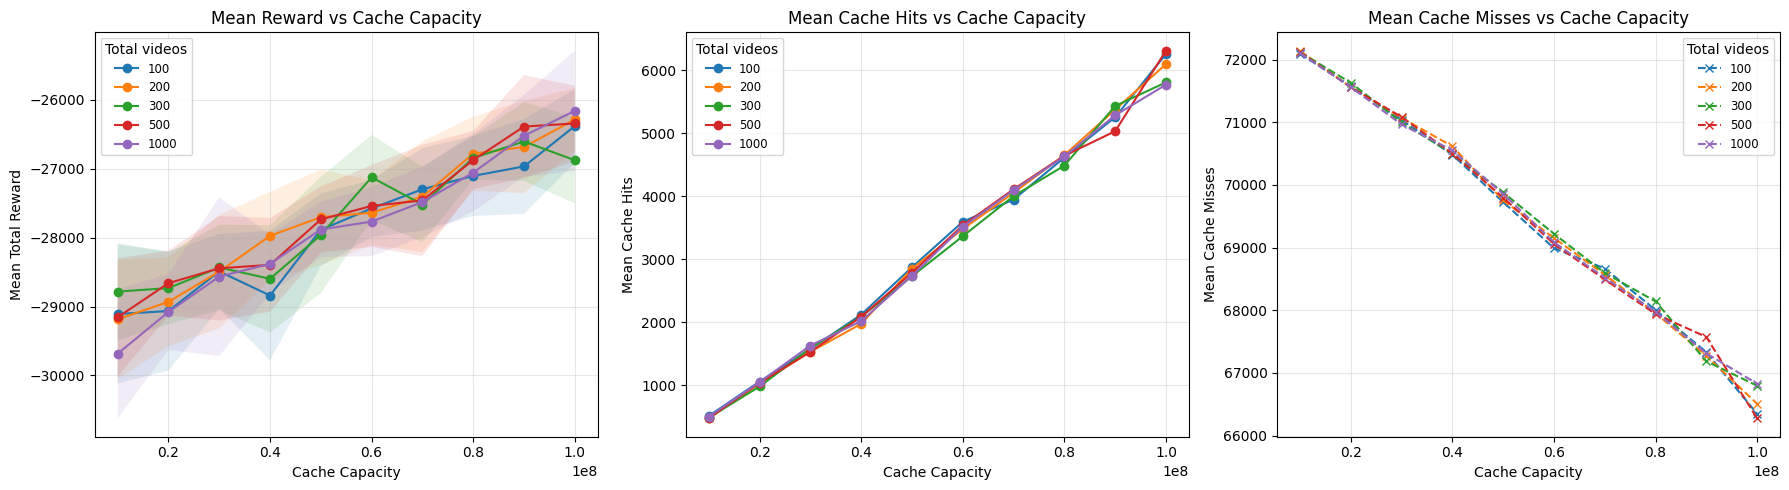

In [20]:
if __name__ == '__main__':
    capacities = [10e6, 20e6, 30e6, 40e6, 50e6, 60e6, 70e6, 80e6, 90e6, 100e6]
    total_videos_list = [100, 200, 300, 500, 1000]

    n_episodes = 10
    n_steps = 60
    n_users = 60
    step_size = 5.0
    n_gops = 60
    n_layers = 2
    n = 4
    lam = 3.7183
    theta = 0.5
    
    # Store results for each total_videos
    results_by_videos = {}

    for total_videos in total_videos_list:
        capacity_results = {}
        for capacity in capacities:
            results = run_episodes(
                n_episodes=n_episodes,
                n_steps=n_steps,
                total_videos=total_videos,
                max_capacity=capacity,
                n_users=n_users,
                step_size=step_size,
                n_gops=n_gops,
                n_layers=n_layers,
                lam=lam,
                theta=theta,
                n=n
            )

            capacity_results[capacity] = results

            print(
                f"Total Videos: {total_videos}, Capacity: {capacity}, "
                f"Mean reward: {results['mean_reward']:.4f}, "
                f"Std reward: {results['std_reward']:.4f}"
            )

        # Store results for this total_videos
        results_by_videos[total_videos] = capacity_results

    # Plot the results
    import matplotlib.pyplot as plt
    caps = capacities

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
    ax_reward, ax_hits, ax_misses = axes

    # Reward (mean ± std as shaded band)
    for total_videos in total_videos_list:
        means = [results_by_videos[total_videos][c]['mean_reward'] for c in caps]
        stds  = [results_by_videos[total_videos][c]['std_reward']  for c in caps]
        ax_reward.plot(caps, means, marker='o', label=f'{total_videos}')
        ax_reward.fill_between(caps,
                               np.array(means) - np.array(stds),
                               np.array(means) + np.array(stds),
                               alpha=0.12)
    ax_reward.set_xlabel('Cache Capacity')
    ax_reward.set_ylabel('Mean Total Reward')
    ax_reward.set_title('Mean Reward vs Cache Capacity')
    ax_reward.grid(alpha=0.3)
    ax_reward.legend(title='Total videos', fontsize='small')

    # Cache hits
    for total_videos in total_videos_list:
        cache_hits = [results_by_videos[total_videos][c]['mean_cache_hits'] for c in caps]
        ax_hits.plot(caps, cache_hits, marker='o', label=f'{total_videos}')
    ax_hits.set_xlabel('Cache Capacity')
    ax_hits.set_ylabel('Mean Cache Hits')
    ax_hits.set_title('Mean Cache Hits vs Cache Capacity')
    ax_hits.grid(alpha=0.3)
    ax_hits.legend(title='Total videos', fontsize='small')

    # Cache misses
    for total_videos in total_videos_list:
        cache_misses = [results_by_videos[total_videos][c]['mean_cache_misses'] for c in caps]
        ax_misses.plot(caps, cache_misses, marker='x', linestyle='--', label=f'{total_videos}')
    ax_misses.set_xlabel('Cache Capacity')
    ax_misses.set_ylabel('Mean Cache Misses')
    ax_misses.set_title('Mean Cache Misses vs Cache Capacity')
    ax_misses.grid(alpha=0.3)
    ax_misses.legend(title='Total videos', fontsize='small')

    plt.tight_layout()
    plt.show()